In [24]:
import duckdb
import polars as pl
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
con = duckdb.connect("../data/m5.db")

In [5]:
con.execute("SHOW TABLES").fetchdf()

,name
0,calendar
1,sales_train_evaluation
2,sales_train_validation
3,sample_submission
4,sell_prices


In [3]:
!ls ../data/processed/*

../data/processed/level_01_daily_total.parquet
../data/processed/level_02_daily_state.parquet
../data/processed/level_03_daily_cat.parquet
../data/processed/level_04_daily_dept.parquet
../data/processed/level_05_daily_state_cat.parquet
../data/processed/level_06_daily_store.parquet
../data/processed/level_07_daily_state_dept.parquet
../data/processed/level_08_daily_store_cat.parquet
../data/processed/level_09_daily_store_dept.parquet
../data/processed/level_10_daily_item.parquet
../data/processed/level_10_weekly_item.parquet
../data/processed/level_11_daily_item_state.parquet
../data/processed/level_11_weekly_item_state.parquet
../data/processed/level_12_daily_item_store.parquet
../data/processed/level_12_weekly_item_store.parquet


In [19]:
!pwd

/home/njimenez/Workspace/magister/forecast-tfm/notebooks


/home/njimenez/Workspace/magister/forecast-tfm/data/processed/level_12_daily_item_store.parquet

In [6]:
DATASET_PATH = "../data/processed/level_12_daily_item_store.parquet"

In [7]:
duckdb.sql(f"""
    SELECT *
    FROM read_parquet('{DATASET_PATH}')
    LIMIT 5
""").df()

,agg_id,item_id,dept_id,cat_id,store_id,state_id,date,sales,gross_sales,avg_sell_price,...,dayofweek,weekofyear,is_weekend,cum7,cum14,cum21,cum28,cum35,cum42,cum364
0,FOODS_1_FOODS_FOODS_1_001_CA_1_CA,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,2011-01-29,3.0,6.0,2.0,...,6,4,1,9.0,16.0,24.0,38.0,53.0,63.0,325.0
1,FOODS_1_FOODS_FOODS_1_001_CA_1_CA,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,2011-01-30,0.0,0.0,NaN,...,7,4,1,9.0,16.0,26.0,40.0,56.0,68.0,329.0
2,FOODS_1_FOODS_FOODS_1_001_CA_1_CA,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,2011-01-31,0.0,0.0,NaN,...,1,5,0,9.0,18.0,26.0,40.0,56.0,68.0,329.0
3,FOODS_1_FOODS_FOODS_1_001_CA_1_CA,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,2011-02-01,1.0,2.0,2.0,...,2,5,0,8.0,18.0,27.0,41.0,56.0,67.0,329.0
4,FOODS_1_FOODS_FOODS_1_001_CA_1_CA,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,2011-02-02,4.0,8.0,2.0,...,3,5,0,4.0,16.0,25.0,38.0,54.0,64.0,325.0


In [18]:
df_by_date = duckdb.sql(f"""
    SELECT
    date,
    SUM(sales) AS sales
    FROM read_parquet('{DATASET_PATH}')
    WHERE date >= '2015-01-01' AND date < '2016-01-01'
    GROUP BY date
    ORDER BY date
""").df()

df_by_date

,date,sales
0,2015-01-01,26452.0
1,2015-01-02,39633.0
2,2015-01-03,41085.0
3,2015-01-04,39647.0
4,2015-01-05,34691.0
...,...,...
360,2015-12-27,35378.0
361,2015-12-28,29964.0
362,2015-12-29,31893.0
363,2015-12-30,34127.0


In [29]:
df_dept_month = duckdb.sql(f"""
    SELECT
        dept_id,
        strftime(date, '%Y-%m') AS year_month,
        SUM(gross_sales) AS total_gross_sales
    FROM read_parquet('{DATASET_PATH}')
    WHERE date >= '2015-01-01' AND date < '2016-01-01'
    GROUP BY dept_id, year_month
    ORDER BY dept_id, year_month
""").df()

df_dept_month['total_gross_sales_pct'] = df_dept_month['total_gross_sales'] / df_dept_month.groupby('dept_id')['total_gross_sales'].transform('sum')
df_dept_month

,dept_id,year_month,total_gross_sales,total_gross_sales_pct
0,FOODS_1,2015-01,238684.199981,0.082036
1,FOODS_1,2015-02,224035.820141,0.077001
2,FOODS_1,2015-03,214346.410058,0.073671
3,FOODS_1,2015-04,227795.809835,0.078293
4,FOODS_1,2015-05,245546.489856,0.084394
...,...,...,...,...
79,HOUSEHOLD_2,2015-08,299684.789229,0.094497
80,HOUSEHOLD_2,2015-09,250424.319437,0.078964
81,HOUSEHOLD_2,2015-10,263914.509270,0.083218
82,HOUSEHOLD_2,2015-11,242463.179319,0.076454


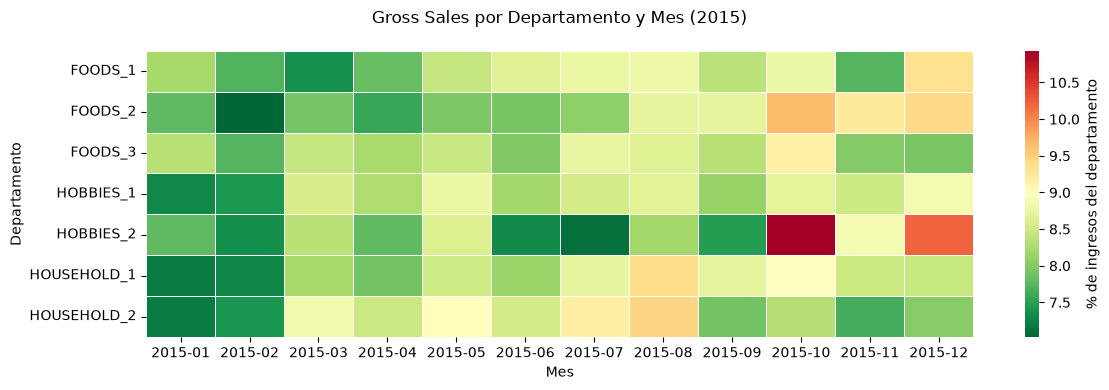

In [103]:
df_plot = df_dept_month.pivot(index='dept_id', columns='year_month', values='total_gross_sales_pct')

ESCALAS_COLORES = {
    "verde-amarillo-rojo": 'RdYlGn_r',
    "amarillo-rojo": 'YlOrRd'
}

df_plot = df_dept_month.pivot(index='dept_id', columns='year_month', values='total_gross_sales_pct')

plt.figure(figsize=(12, 4))
ax = sns.heatmap(
    df_plot * 100, cmap=ESCALAS_COLORES['verde-amarillo-rojo'], annot=False, linewidths=0.5,
    cbar_kws={'label': '% de ingresos del departamento'}
)
plt.title('Gross Sales por Departamento y Mes (2015)', pad=20, fontsize=12)
plt.xlabel('Mes')
plt.ylabel('Departamento')
plt.tight_layout()
plt.show()

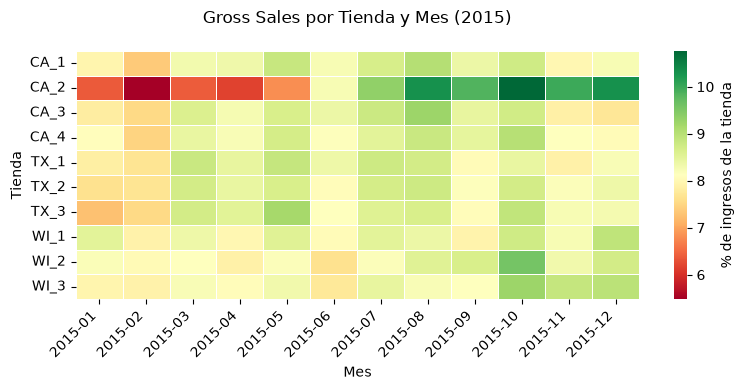

In [ ]:
df_store_month = duckdb.sql(f"""
    SELECT
        store_id,
        strftime(date, '%Y-%m') AS year_month,
        SUM(gross_sales) AS total_gross_sales
    FROM read_parquet('{DATASET_PATH}')
    WHERE date >= '2015-01-01' AND date < '2016-01-01'
    GROUP BY store_id, year_month
    ORDER BY store_id, year_month
""").df()

df_store_month['total_gross_sales_pct'] = df_store_month['total_gross_sales'] / df_store_month.groupby('store_id')['total_gross_sales'].transform('sum')

df_plot = df_store_month.pivot(index='store_id', columns='year_month', values='total_gross_sales_pct')

ESCALAS_COLORES = {
    "verde-amarillo-rojo": 'RdYlGn',
    "amarillo-rojo": 'YlOrRd'
}

plt.figure(figsize=(8, 4))
ax = sns.heatmap(
    df_plot * 100, cmap=ESCALAS_COLORES['verde-amarillo-rojo'], annot=False, linewidths=0.5,
    cbar_kws={'label': '% de ingresos de la tienda'}
)
plt.title('Gross Sales por Tienda y Mes (2015)', pad=20, fontsize=12)
plt.xlabel('Mes')
plt.ylabel('Tienda')
plt.yticks(rotation=0)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

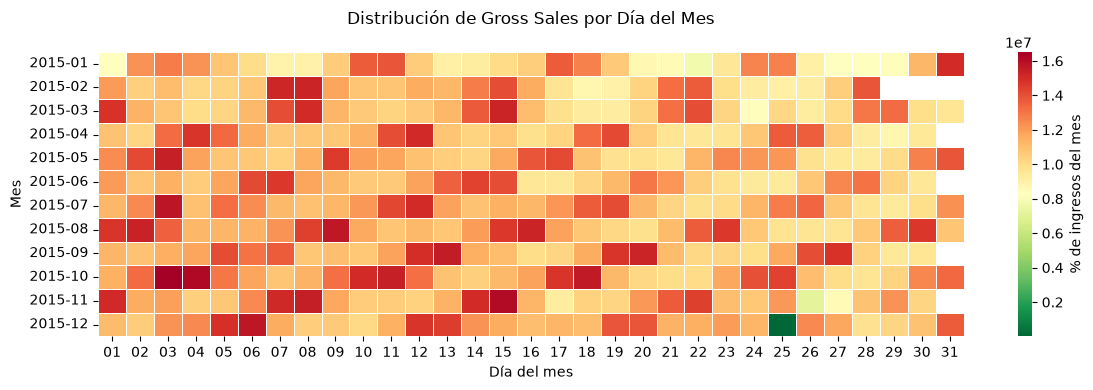

In [100]:
df_day_month = duckdb.sql(f"""
    SELECT
        strftime(date, '%d') AS day,
        strftime(date, '%Y-%m') AS year_month,
        SUM(gross_sales) AS total_gross_sales
    FROM read_parquet('{DATASET_PATH}')
    WHERE date >= '2015-01-01' AND date < '2016-01-01'
    GROUP BY strftime(date, '%d'), strftime(date, '%Y-%m')
    ORDER BY year_month, day
""").df()

df_day_month['total_gross_sales_pct'] = (
    df_day_month.groupby('year_month')['total_gross_sales']
    .transform(lambda x: x / x.sum())
)

pivot = df_day_month.pivot(index='year_month', columns='day', values='total_gross_sales')

plt.figure(figsize=(12, 4))
ax = sns.heatmap(
    pivot * 100, cmap='RdYlGn_r', annot=False, linewidths=0.5,
    cbar_kws={'label': '% de ingresos del mes'}
)
plt.title('Distribución de Gross Sales por Día del Mes', pad=20, fontsize=12)
plt.xlabel('Día del mes')
plt.ylabel('Mes')
plt.tight_layout()
plt.show()

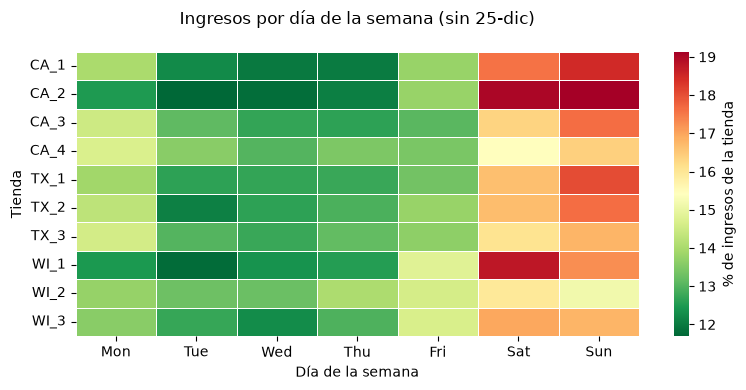

In [99]:
df_store_dow = duckdb.sql(f"""
    SELECT
        store_id,
        strftime(date, '%a') AS day_of_week,
        SUM(gross_sales) AS total_gross_sales
    FROM read_parquet('{DATASET_PATH}')
    WHERE date >= '2015-01-01' AND date < '2016-01-01'
        AND date != '2015-12-25'
    GROUP BY store_id, strftime(date, '%a')
    ORDER BY store_id, day_of_week
""").df()

df_store_dow['total_gross_sales_pct'] = (
    df_store_dow.groupby('store_id')['total_gross_sales']
    .transform(lambda x: x / x.sum())
)

dow_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
pivot = df_store_dow.pivot(index='store_id', columns='day_of_week', values='total_gross_sales_pct')
pivot = pivot[dow_order]

plt.figure(figsize=(8, 4))
ax = sns.heatmap(
    pivot * 100, cmap='RdYlGn_r', annot=False, linewidths=0.5,
    cbar_kws={'label': '% de ingresos de la tienda'}
)
plt.title('Ingresos por día de la semana (sin 25-dic)', pad=20, fontsize=12)
plt.xlabel('Día de la semana')
plt.ylabel('Tienda')
plt.tight_layout()
plt.show()